# 1.3 Preprocessed Data — Exploratory Data Analysis

Explore the preprocessed house data to uncover patterns, distributions, and relationships.

**Steps:**
1. Load preprocessed data
2. Analyze target variable (price)
3. Explore numerical feature distributions
4. Analyze categorical features
5. Examine correlations
6. Identify key insights

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
sns.set_palette('husl')

## 1.3.1 Load Preprocessed Data

In [2]:
df = pd.read_csv('../data/data_preprocessed_train.csv')

print(f'Loaded {df.shape[0]} rows and {df.shape[1]} columns')
df.head()


Loaded 67 rows and 8 columns


,price,sqft,bedrooms,bathrooms,location,year_built,condition,house_age
0,730000.0,2620,3,2.5,Downtown,1994,Excellent,32
1,312000.0,1680,2,1.5,Rural,1959,Fair,67
2,520000.0,2050,3,2.0,Urban,1990,Good,36
3,615000.0,2230,3,2.0,Downtown,1986,Good,40
4,398000.0,1680,2,2.0,Suburb,1968,Fair,58


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 67 entries, 0 to 66
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   price       67 non-null     float64
 1   sqft        67 non-null     int64  
 2   bedrooms    67 non-null     int64  
 3   bathrooms   67 non-null     float64
 4   location    67 non-null     object 
 5   year_built  67 non-null     int64  
 6   condition   67 non-null     object 
 7   house_age   67 non-null     int64  
dtypes: float64(2), int64(4), object(2)
memory usage: 4.3+ KB


## 1.3.2 Target Variable Analysis: Price

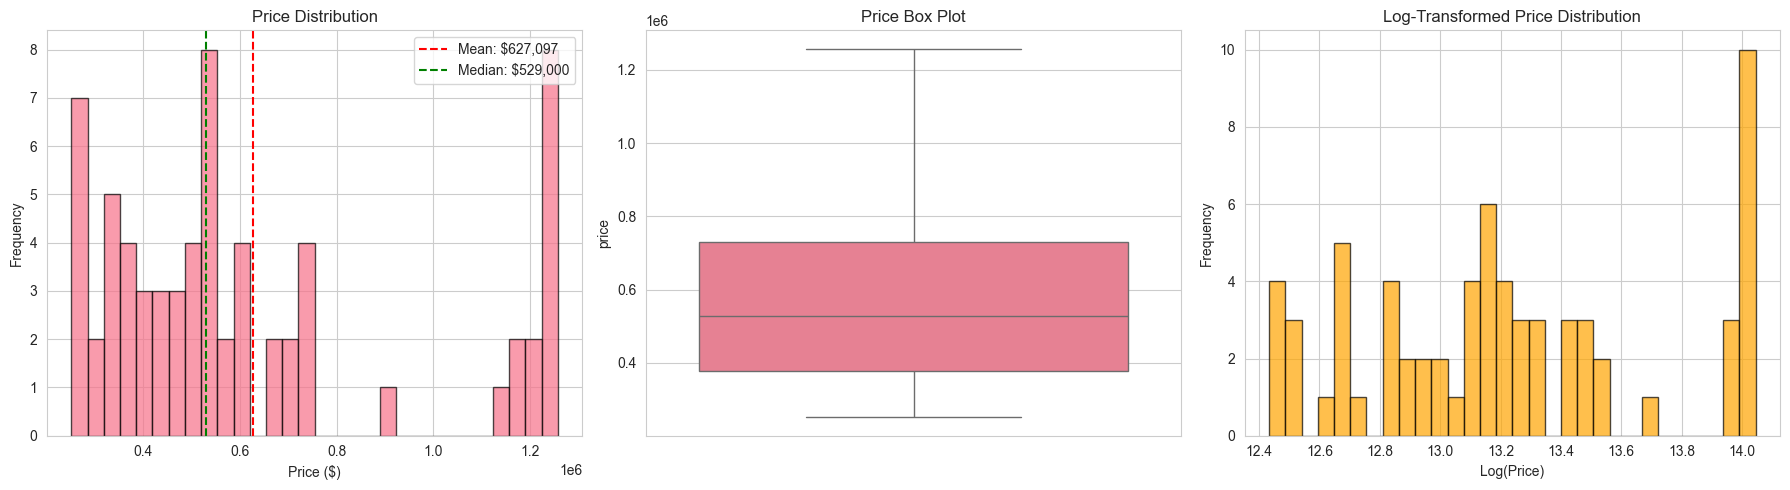


Price Statistics:
  Mean:   $  627,097.01
  Median: $  529,000.00
  Std:    $  329,534.98
  Min:    $  251,000.00
  Max:    $1,257,500.00
  Skewness: 0.970
  Kurtosis: -0.369


In [4]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].hist(df['price'], bins=30, edgecolor='black', alpha=0.7)
axes[0].set_title('Price Distribution')
axes[0].set_xlabel('Price ($)')
axes[0].set_ylabel('Frequency')
axes[0].axvline(df['price'].mean(), color='red', linestyle='--', label=f'Mean: ${df["price"].mean():,.0f}')
axes[0].axvline(df['price'].median(), color='green', linestyle='--', label=f'Median: ${df["price"].median():,.0f}')
axes[0].legend()

sns.boxplot(y=df['price'], ax=axes[1])
axes[1].set_title('Price Box Plot')

axes[2].hist(np.log1p(df['price']), bins=30, edgecolor='black', alpha=0.7, color='orange')
axes[2].set_title('Log-Transformed Price Distribution')
axes[2].set_xlabel('Log(Price)')
axes[2].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

print(f'\nPrice Statistics:')
print(f'  Mean:   ${df["price"].mean():>12,.2f}')
print(f'  Median: ${df["price"].median():>12,.2f}')
print(f'  Std:    ${df["price"].std():>12,.2f}')
print(f'  Min:    ${df["price"].min():>12,.2f}')
print(f'  Max:    ${df["price"].max():>12,.2f}')
print(f'  Skewness: {df["price"].skew():.3f}')
print(f'  Kurtosis: {df["price"].kurtosis():.3f}')

## 1.3.3 Numerical Feature Distributions

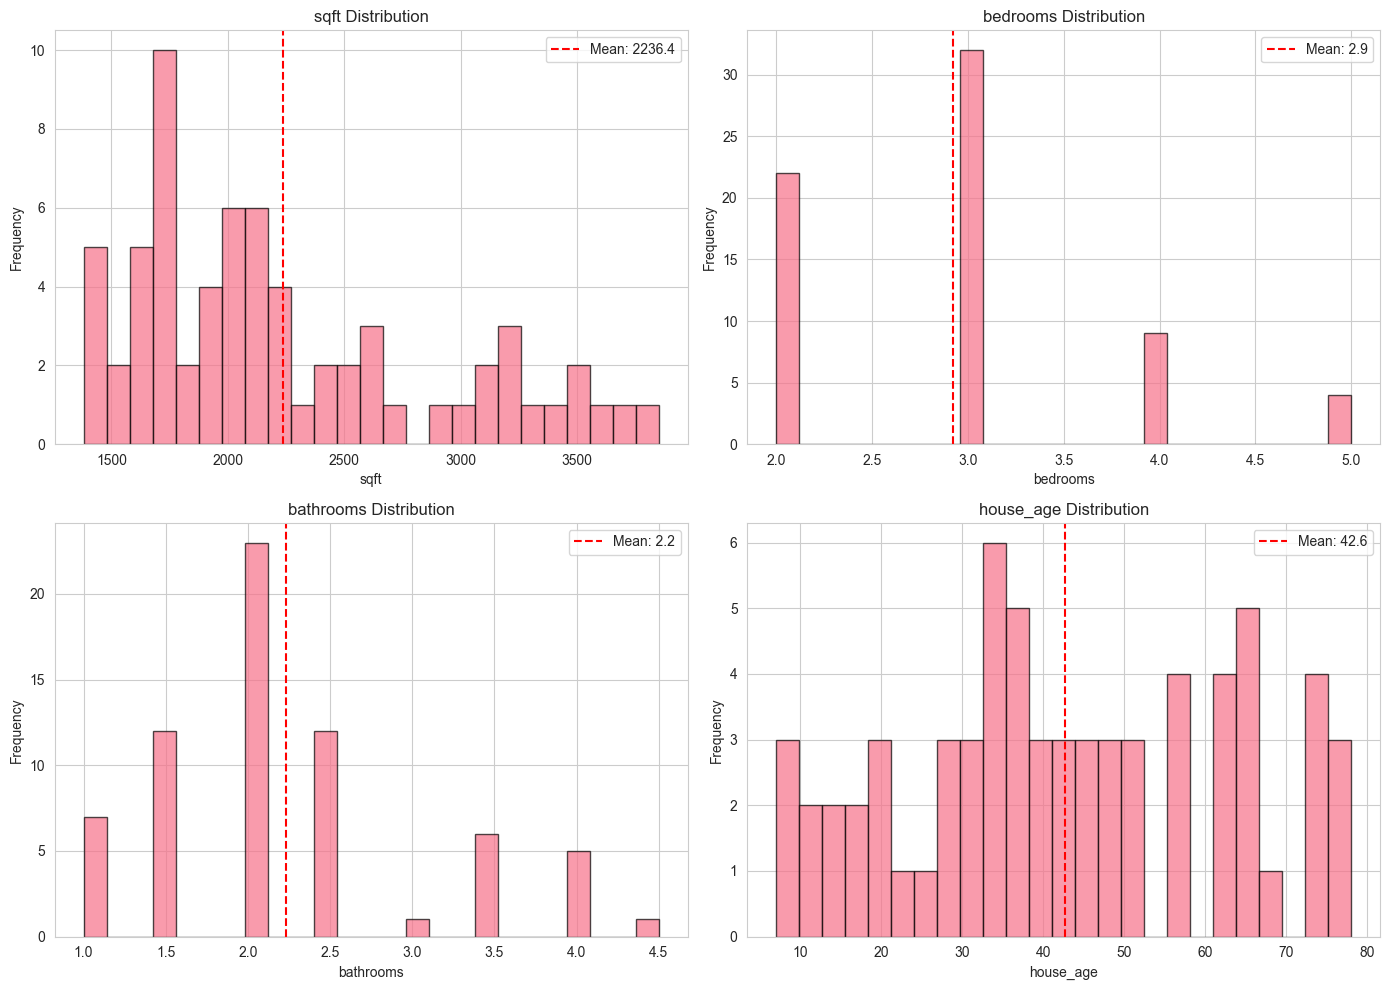

,sqft,bedrooms,bathrooms,house_age
count,67.00,67.00,67.00,67.00
mean,2236.40,2.93,2.23,42.64
std,662.27,0.84,0.87,19.59
min,1380.00,2.00,1.00,7.00
25%,1720.00,2.00,1.50,30.00
50%,2050.00,3.00,2.00,41.00
75%,2600.00,3.00,2.50,59.50
max,3850.00,5.00,4.50,78.00


In [5]:
numerical_features = ['sqft', 'bedrooms', 'bathrooms', 'house_age']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for i, col in enumerate(numerical_features):
    ax = axes[i // 2, i % 2]
    ax.hist(df[col], bins=25, edgecolor='black', alpha=0.7)
    ax.set_title(f'{col} Distribution')
    ax.set_xlabel(col)
    ax.set_ylabel('Frequency')
    ax.axvline(df[col].mean(), color='red', linestyle='--', label=f'Mean: {df[col].mean():.1f}')
    ax.legend()

plt.tight_layout()
plt.show()

df[numerical_features].describe().round(2)

## 1.3.4 Categorical Feature Analysis

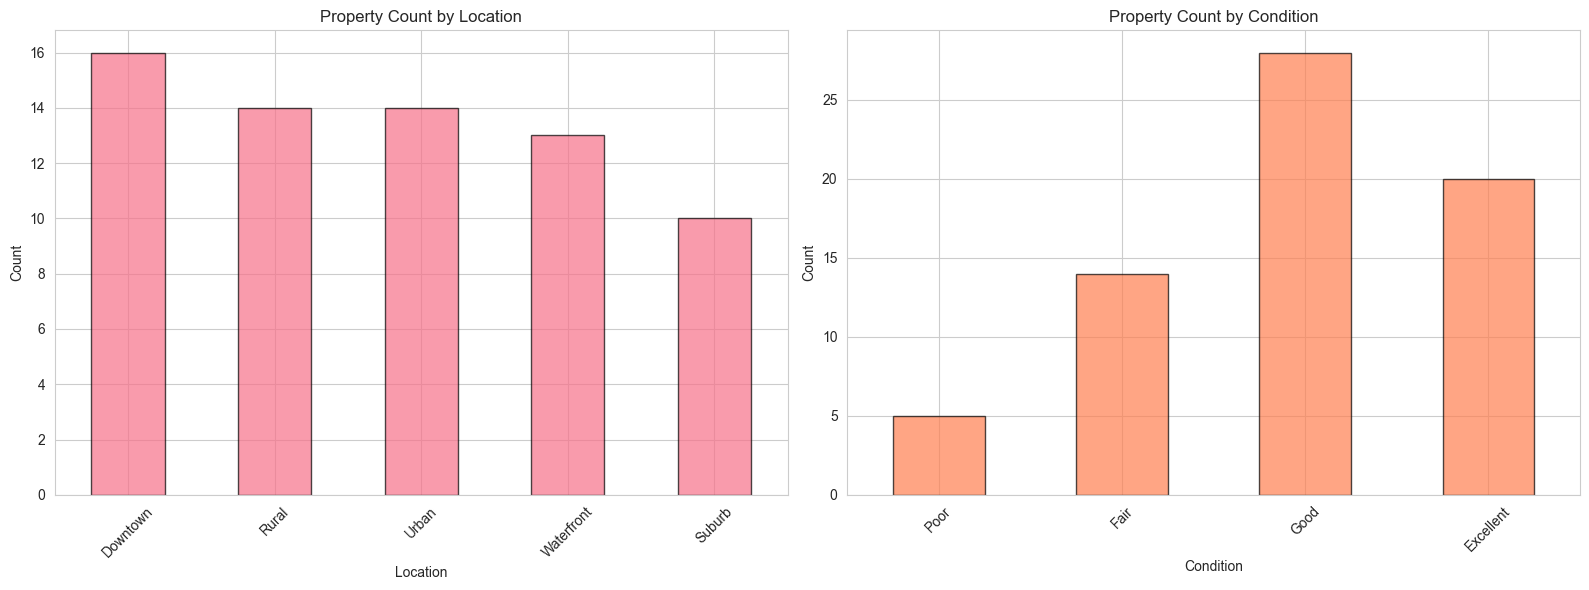

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

location_counts = df['location'].value_counts()
location_counts.plot(kind='bar', ax=axes[0], edgecolor='black', alpha=0.7)
axes[0].set_title('Property Count by Location')
axes[0].set_xlabel('Location')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=45)

condition_order = ['Poor', 'Fair', 'Good', 'Excellent']
condition_counts = df['condition'].value_counts().reindex(condition_order)
condition_counts.plot(kind='bar', ax=axes[1], edgecolor='black', alpha=0.7, color='coral')
axes[1].set_title('Property Count by Condition')
axes[1].set_xlabel('Condition')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

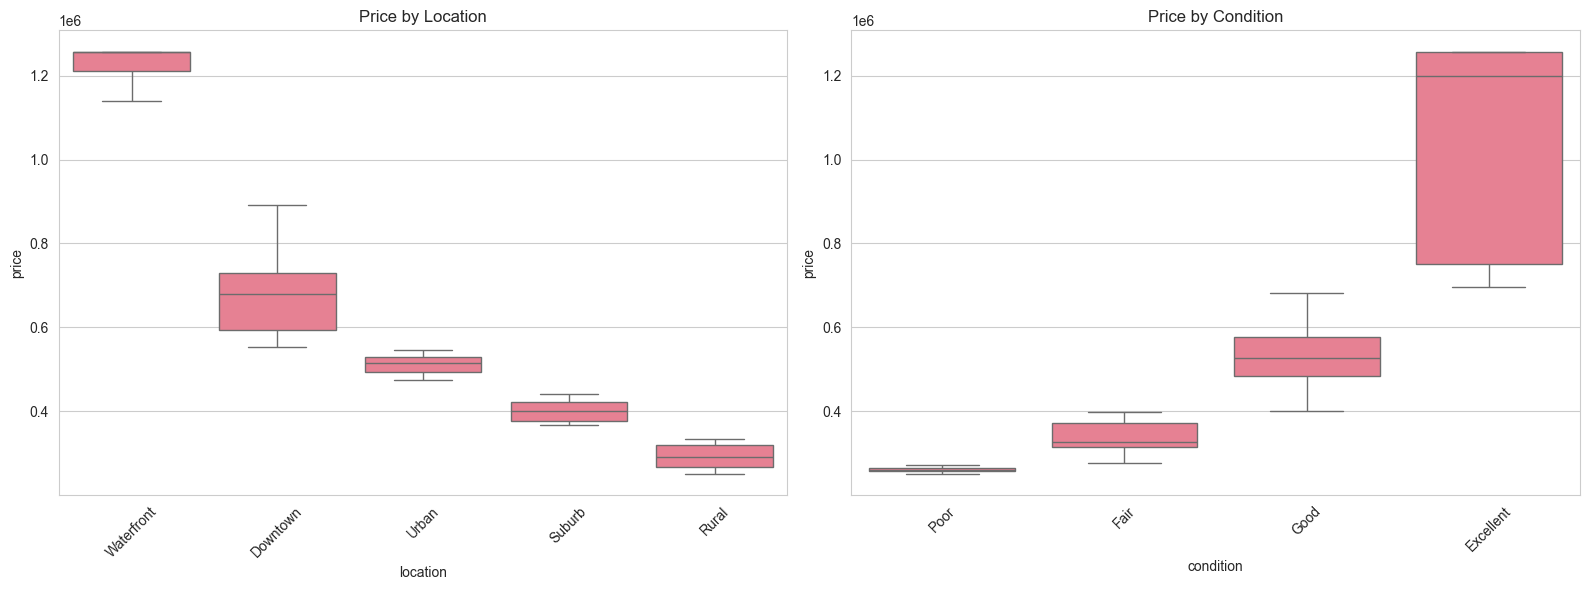


Median Price by Location:
               median       mean  count
location                               
Waterfront  1257500.0  1229423.0     13
Downtown     678500.0   671125.0     16
Urban        516000.0   512929.0     14
Suburb       399500.0   401200.0     10
Rural        290500.0   293000.0     14

Median Price by Condition:
              median       mean  count
condition                             
Poor        261000.0   261200.0      5
Fair        326500.0   334929.0     14
Good        528000.0   527964.0     28
Excellent  1200000.0  1061875.0     20


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

location_order = df.groupby('location')['price'].median().sort_values(ascending=False).index
sns.boxplot(data=df, x='location', y='price', order=location_order, ax=axes[0])
axes[0].set_title('Price by Location')
axes[0].tick_params(axis='x', rotation=45)

sns.boxplot(data=df, x='condition', y='price', order=condition_order, ax=axes[1])
axes[1].set_title('Price by Condition')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

print('\nMedian Price by Location:')
print(df.groupby('location')['price'].agg(['median', 'mean', 'count']).round(0).sort_values('median', ascending=False))
print('\nMedian Price by Condition:')
print(df.groupby('condition')['price'].agg(['median', 'mean', 'count']).round(0).reindex(condition_order))

## 1.3.5 Correlation Analysis

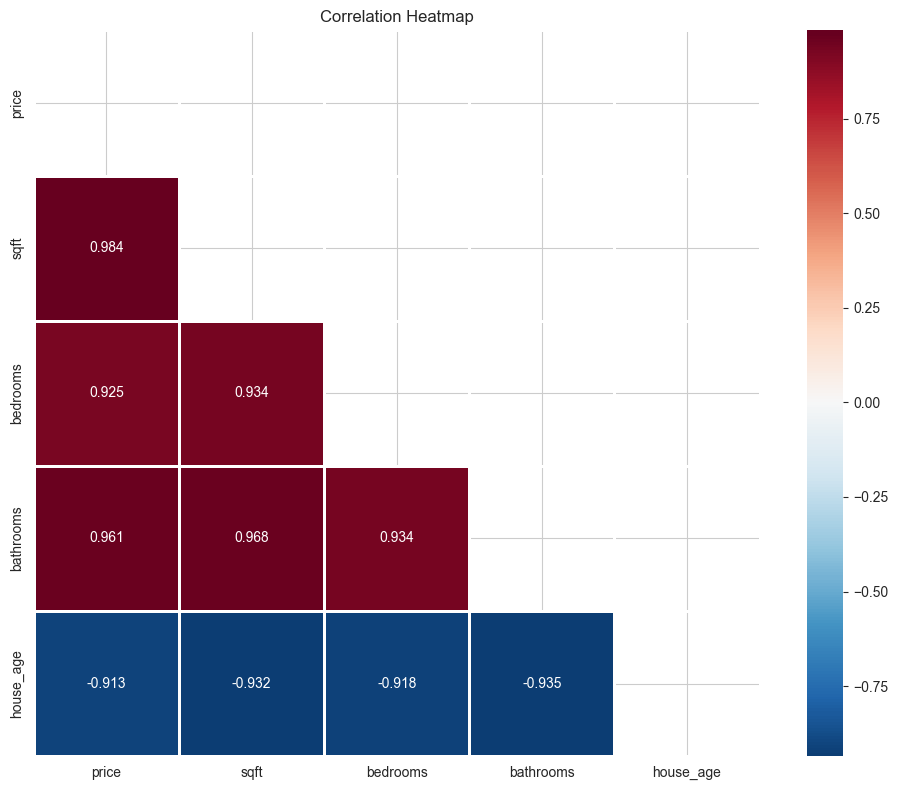


Correlation with Price:
sqft         0.984
bathrooms    0.961
bedrooms     0.925
house_age   -0.913
Name: price, dtype: float64


In [8]:
corr_cols = ['price', 'sqft', 'bedrooms', 'bathrooms', 'house_age']
corr_matrix = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.3f', cmap='RdBu_r',
            center=0, square=True, linewidths=1, ax=ax)
ax.set_title('Correlation Heatmap')
plt.tight_layout()
plt.show()

print('\nCorrelation with Price:')
print(corr_matrix['price'].drop('price').sort_values(ascending=False).round(3))

## 1.3.6 Pairwise Relationships

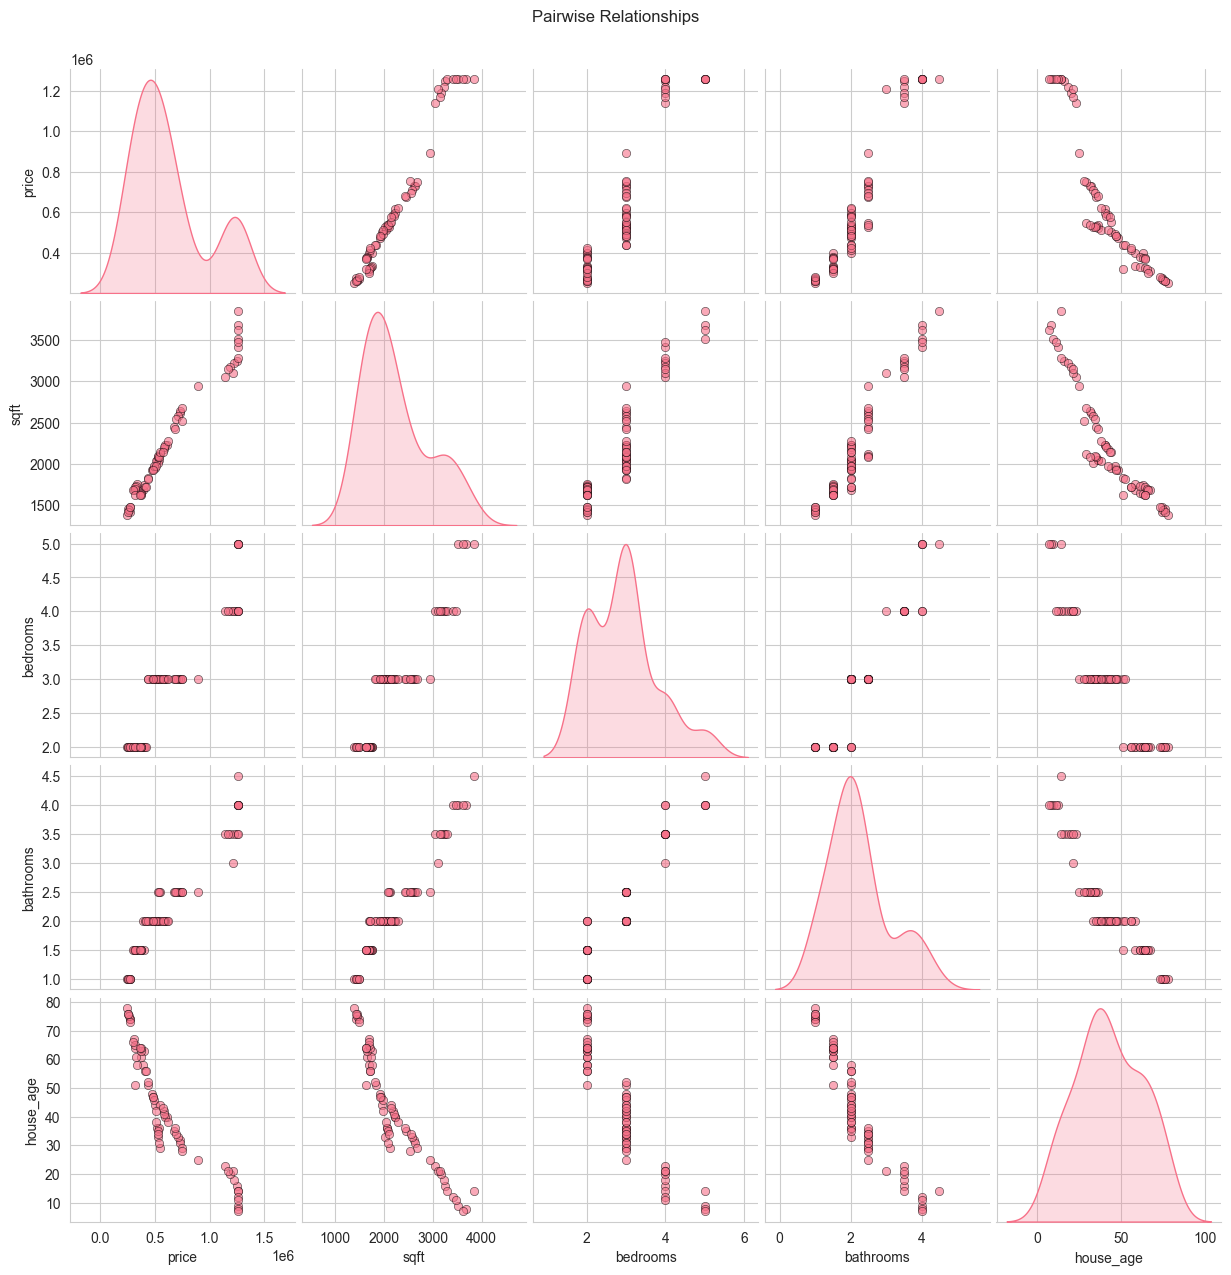

In [9]:
g = sns.pairplot(df[['price', 'sqft', 'bedrooms', 'bathrooms', 'house_age']],
                 diag_kind='kde', plot_kws={'alpha': 0.6, 'edgecolor': 'k', 'linewidth': 0.5})
g.fig.suptitle('Pairwise Relationships', y=1.02)
plt.show()

## 1.3.7 Key Feature vs Price

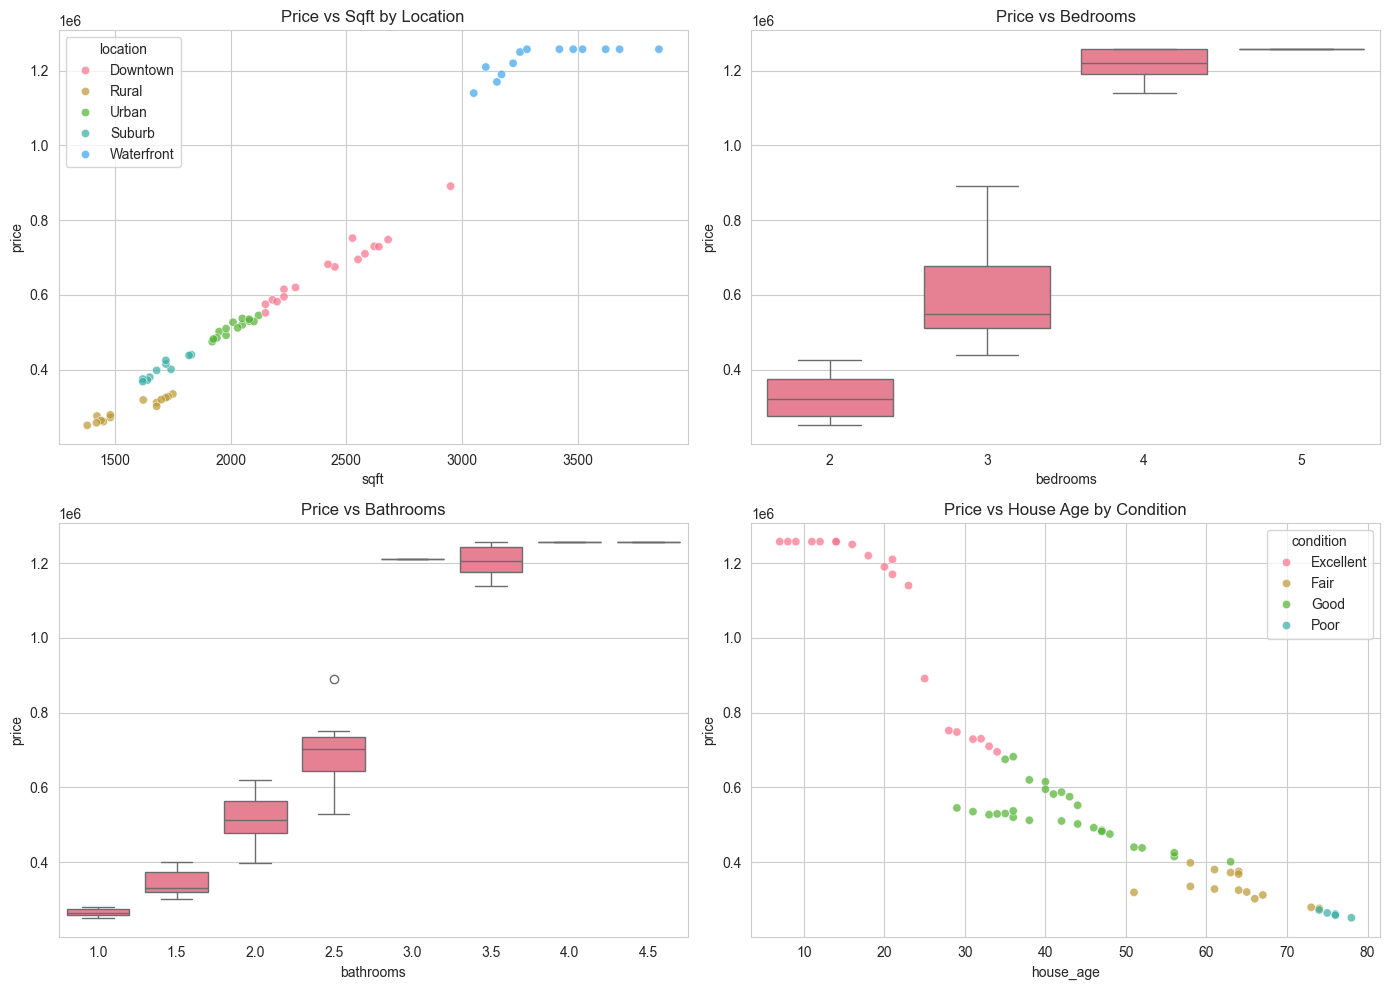

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.scatterplot(data=df, x='sqft', y='price', hue='location', alpha=0.7, ax=axes[0, 0])
axes[0, 0].set_title('Price vs Sqft by Location')

sns.boxplot(data=df, x='bedrooms', y='price', ax=axes[0, 1])
axes[0, 1].set_title('Price vs Bedrooms')

sns.boxplot(data=df, x='bathrooms', y='price', ax=axes[1, 0])
axes[1, 0].set_title('Price vs Bathrooms')

sns.scatterplot(data=df, x='house_age', y='price', hue='condition', alpha=0.7, ax=axes[1, 1])
axes[1, 1].set_title('Price vs House Age by Condition')

plt.tight_layout()
plt.show()

## 1.3.8 Key Insights

In [11]:
print('=== KEY INSIGHTS ===')
print(f'\n1. Price range: ${df["price"].min():,.0f} to ${df["price"].max():,.0f}')
print(f'2. Most expensive location: {df.groupby("location")["price"].median().idxmax()} (median ${df.groupby("location")["price"].median().max():,.0f})')
print(f'3. Most affordable location: {df.groupby("location")["price"].median().idxmin()} (median ${df.groupby("location")["price"].median().min():,.0f})')
print(f'4. Strongest correlation with price: sqft (r={df["price"].corr(df["sqft"]):.3f})')
print(f'5. Price distribution skewness: {df["price"].skew():.3f} (consider log transform)')
print(f'6. Average house age: {df["house_age"].mean():.1f} years')

=== KEY INSIGHTS ===

1. Price range: $251,000 to $1,257,500
2. Most expensive location: Waterfront (median $1,257,500)
3. Most affordable location: Rural (median $290,500)
4. Strongest correlation with price: sqft (r=0.984)
5. Price distribution skewness: 0.970 (consider log transform)
6. Average house age: 42.6 years
